# Topic Clustering Evaluation

## Utils

In [1]:
import pandas as pd
import pyarrow
import numpy as np

## Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# df_path = "/home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet"

df_path = '/content/drive/Shareddrives/KeyBoostAuthor/Labeled_Dataset_with_Topic_NER/processed_Ecuador_part_all.gzip.parquet'
df = pd.read_parquet(df_path)

In [4]:
print("df shape:", df.shape)
print("df columns:", df.columns)

df shape: (1468565, 29)
df columns: Index(['postid', 'post_text', 'application_name', 'post_language',
       'in_reply_to_postid', 'in_reply_to_accountid', 'post_time', 'accountid',
       'account_profile_description', 'follower_count', 'following_count',
       'account_creation_date', 'is_repost', 'reposted_accountid',
       'reposted_postid', 'hashtags', 'urls', 'account_mentions', 'is_control',
       'clean_text_with_entities', 'clean_text_without_enteties',
       'translated_post', 'BERTopic_topic_512', 'BERTopic_prob512',
       'BERTopic_topic_256', 'BERTopic_prob256', 'BERTopic_topic_128',
       'BERTopic_prob128', 'ner_entities'],
      dtype='object')


In [10]:
df[['postid','post_text','post_time','translated_post','BERTopic_topic_512', 'BERTopic_prob512',
       'BERTopic_topic_256', 'BERTopic_prob256', 'BERTopic_topic_128',
       'BERTopic_prob128']]

,postid,post_text,post_time,translated_post,BERTopic_topic_512,BERTopic_prob512,BERTopic_topic_256,BERTopic_prob256,BERTopic_topic_128,BERTopic_prob128
0,0bafe020a260495bee38b98fde83668d924454019b,Vamos a cambiar la forma de hacer comunicación corporativa,2010-03-13 02:52:00,going change way corporate communication done.,-1,0.722297,0,0.672197,4,0.694254
1,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,"Damos servicio de manejo de prensa, elaboración estrategias de comunicación, manejo de crisis, media training, think tank, lobbyng...",2010-03-13 03:08:00,"provide media management services, communication strategies, crisis management, media training, tank, lobbying...",-1,0.651021,0,0.622568,82,0.756225
2,514b2c38b26e240cac85382be74ed7d61a02468ac1,"@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bueno se estan destapando mascaras, ya pueden a ser una nueva Pelicula ""La Mascara Reloader""",2010-03-13 15:26:00,"well, masks unveiled, new movie ""the reloader mask""",0,0.596310,0,0.605958,18,0.694943
3,e82a816068e88387d19430348f0420b040e0d11b4e,"Mario, debemos denuciar que en los poderes publicos, hay mucho chavista disfrazado maltratando al publico y eso es negativo para el pueblo.",2010-03-13 15:32:00,"mario, must denounce public authorities, lot chavista disguise abusing public negative people.",-1,0.675815,0,0.680324,2,0.801221
4,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,"Tambien debemos estar claro que la oposición esta invirtiendo en la delicuencia, para atacar el gobierno y que la policia nacional funcione",2010-03-13 15:35:00,"must also clear opposition investing crime, attack government national police work.",-1,0.625230,0,0.557243,0,0.673560
...,...,...,...,...,...,...,...,...,...,...
1468560,7d4943612fa49e3383aaf35e574c57100440f05c19,". @110b1dc0680903c6b445844bb2b114643eb1e6f837 en su compromiso de garantizar la educación para personas en situación de escolaridad inconclusa, cuenta con 3.192 docentes capacitados en procesos formativos de jóvenes y adultos #TodosABC. https://5150ca8fe6e51756d4420bbcee9d53da435854e249",2019-07-30 23:59:36,". <user> commitment ensuring education unfinished schooling, 3,192 teachers trained training processes young adults world. <url>",-1,0.728308,0,0.653372,15,0.826072
1468561,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,"AHORA | Vicepresidente de la República, @7cb40e447bc7687a413d1436fbbf145a23dbbe3c54, ministra de Educación, @a348071bbdded88a94ec657f3e0b7790c12e2a0698, ministra del @a56426459c348e6fb4a8411743259b2b283e69e165, @e40e962a593739b49a2e8e3872926d6130763d509c y autoridades de Estado participan en la Graduación de estudiantes de Bachillerato de la Campaña #TodosABC, 2017-2019, en Quito. https://b43da03566a2af1bce7f3b0d19662e400e990d3b3e",2019-07-30 23:59:45,"vice president republic, user, minister education, user, minister user, user state authorities participating graduation allabc's 2017-2019 campaign bachelor students.",-1,0.719401,0,0.603348,15,0.753167
1468562,c3e606bde49d62fd51fbcf381b647f7713af4675dd,"La Campaña #TodosABC cuenta con un diseño curricular y material educativo específico para jóvenes y adultos, adaptado a sus necesidades y realidades. https://c7964c9109331e1466df59167ca6328d9179eb4558",2019-07-30 23:59:48,"allabc campaign specific curriculum design educational material young adults, tailored realities.",-1,0.686315,30,0.594634,15,0.774811
1468563,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,"A escala nacional en el 2019, alrededor de 134 mil estudiantes continúan en las aulas gracias a la Campaña #TodosABC https://e29f685100f6f94969705abf7992942dacc01c46ae",2019-07-30 23:59:51,"nationally 2019, 134 thousand students continue classroom thanks allabc <url> campaign",-1,0.667672,0,0.605200,15,0.809461


## Report

In [12]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 9.6 MB/s eta 0:00:00


In [13]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

texts = df["translated_post"].fillna("").tolist()
tokenized_texts = [doc.split() for doc in texts]

dictionary = Dictionary(tokenized_texts)

def extract_topic_words_from_df(df, topic_col, text_col, top_n=10):

    topics_words = []

    for topic_id in df[topic_col].unique():

        if topic_id == -1:
            continue

        docs = df[df[topic_col] == topic_id][text_col].dropna().tolist()

        if len(docs) < 5:
            continue

        vectorizer = TfidfVectorizer(max_features=5000)
        X = vectorizer.fit_transform(docs)

        scores = np.asarray(X.mean(axis=0)).flatten()
        words = np.array(vectorizer.get_feature_names_out())

        top_words = words[scores.argsort()[::-1][:top_n]]

        topics_words.append(list(top_words))

    return topics_words

def compute_coherence_from_df(df, topic_col, text_col):

    topics_words = extract_topic_words_from_df(df, topic_col, text_col)

    coherence_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    return coherence_model.get_coherence()

In [16]:
coh_512 = compute_coherence_from_df(df, "BERTopic_topic_512", "translated_post")
coh_256 = compute_coherence_from_df(df, "BERTopic_topic_256", "translated_post")
coh_128 = compute_coherence_from_df(df, "BERTopic_topic_128", "translated_post")

print(coh_512, coh_256, coh_128)

0.5723438129409142 0.5204773867332979 0.4980855442342023


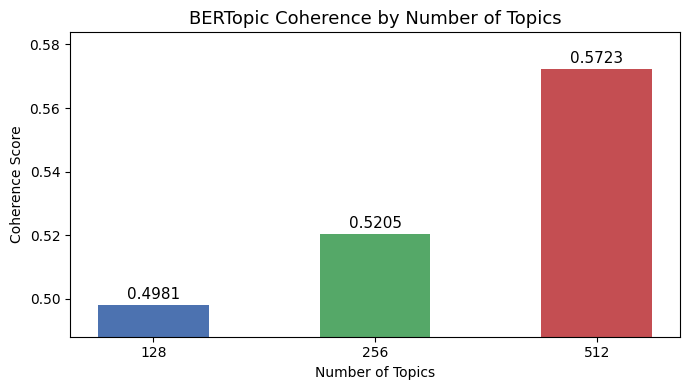

In [17]:
import matplotlib.pyplot as plt

configs = ['128', '256', '512']
scores = [coh_128, coh_256, coh_512]

plt.figure(figsize=(7, 4))
bars = plt.bar(configs, scores, color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11)

plt.title('BERTopic Coherence by Number of Topics', fontsize=13)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.ylim(min(scores) * 0.98, max(scores) * 1.02)
plt.tight_layout()
plt.show()

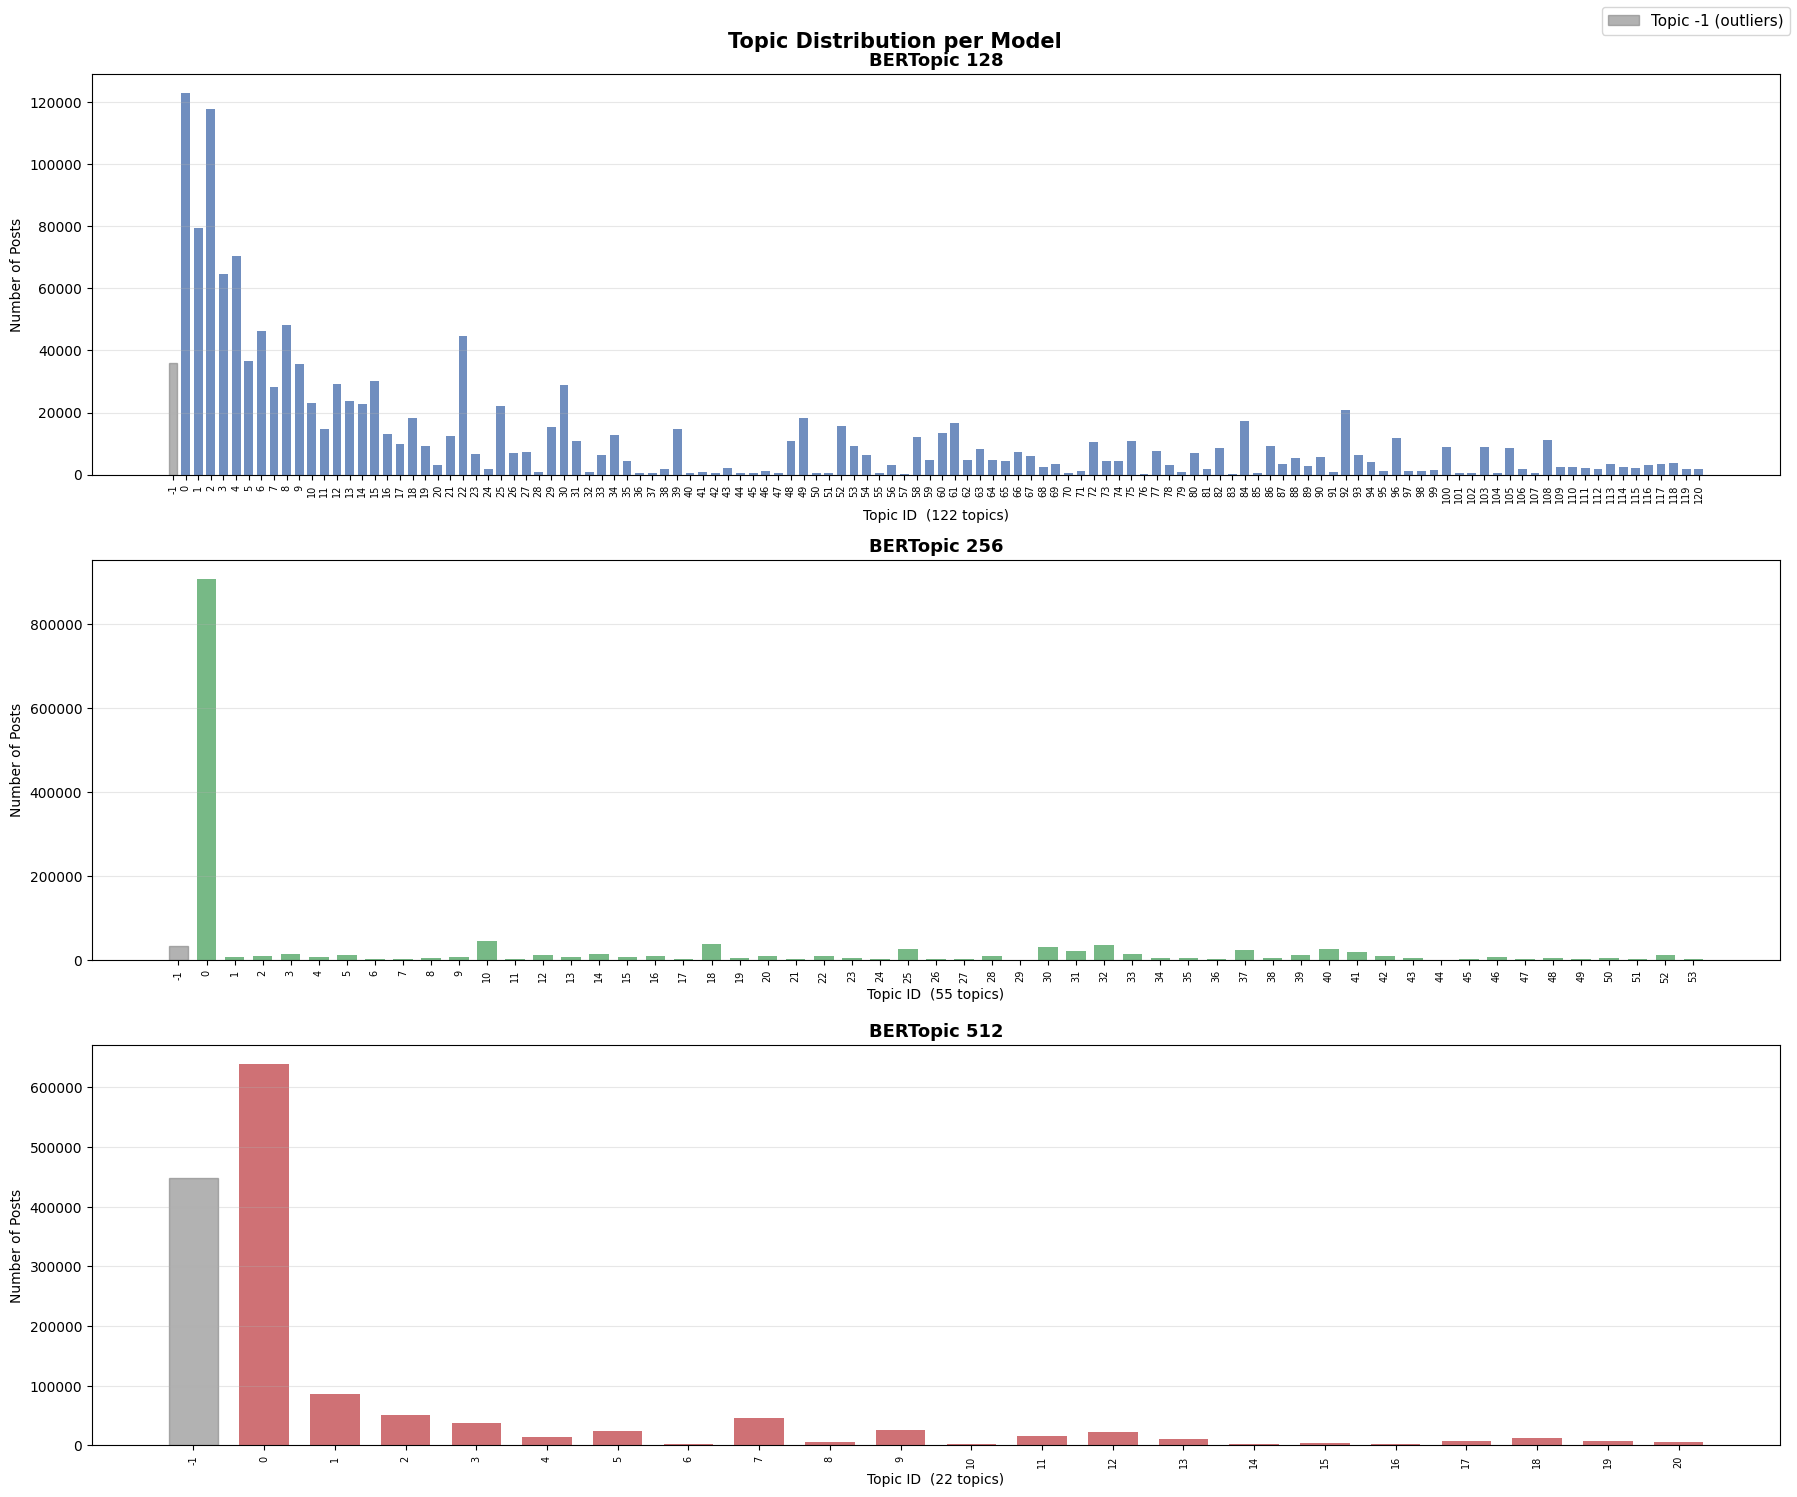

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

models = [
    ('BERTopic_topic_128', 'BERTopic 128', '#4C72B0'),
    ('BERTopic_topic_256', 'BERTopic 256', '#55A868'),
    ('BERTopic_topic_512', 'BERTopic 512', '#C44E52'),
]

for ax, (col, title, color) in zip(axes, models):
    topic_counts = df[col].value_counts().sort_index()
    x_pos = range(len(topic_counts))

    bars = ax.bar(x_pos, topic_counts.values, color=color, alpha=0.8, width=0.7)

    # Highlight -1 in gray
    for bar, idx in zip(bars, topic_counts.index):
        if idx == -1:
            bar.set_color('gray')
            bar.set_alpha(0.6)

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(topic_counts.index.astype(str), rotation=90, fontsize=7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Posts')
    ax.set_xlabel(f'Topic ID  ({len(topic_counts)} topics)')
    ax.grid(axis='y', alpha=0.3)

gray_patch = mpatches.Patch(color='gray', alpha=0.6, label='Topic -1 (outliers)')
fig.legend(handles=[gray_patch], loc='upper right', fontsize=11)

plt.suptitle('Topic Distribution per Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
for col, title in [('BERTopic_topic_128', 'BERTopic 128'),
                   ('BERTopic_topic_256', 'BERTopic 256'),
                   ('BERTopic_topic_512', 'BERTopic 512')]:
    total = len(df)
    for topic in [-1, 0, 1]:
        count = (df[col] == topic).sum()
        pct = count / total * 100
        print(f"{title} | Topic {topic}: {count:,} posts ({pct:.1f}%)")
    print()

BERTopic 128 | Topic -1: 35,899 posts (2.4%)
BERTopic 128 | Topic 0: 122,847 posts (8.4%)
BERTopic 128 | Topic 1: 79,332 posts (5.4%)

BERTopic 256 | Topic -1: 34,368 posts (2.3%)
BERTopic 256 | Topic 0: 907,351 posts (61.8%)
BERTopic 256 | Topic 1: 7,908 posts (0.5%)

BERTopic 512 | Topic -1: 448,068 posts (30.5%)
BERTopic 512 | Topic 0: 639,124 posts (43.5%)
BERTopic 512 | Topic 1: 85,655 posts (5.8%)



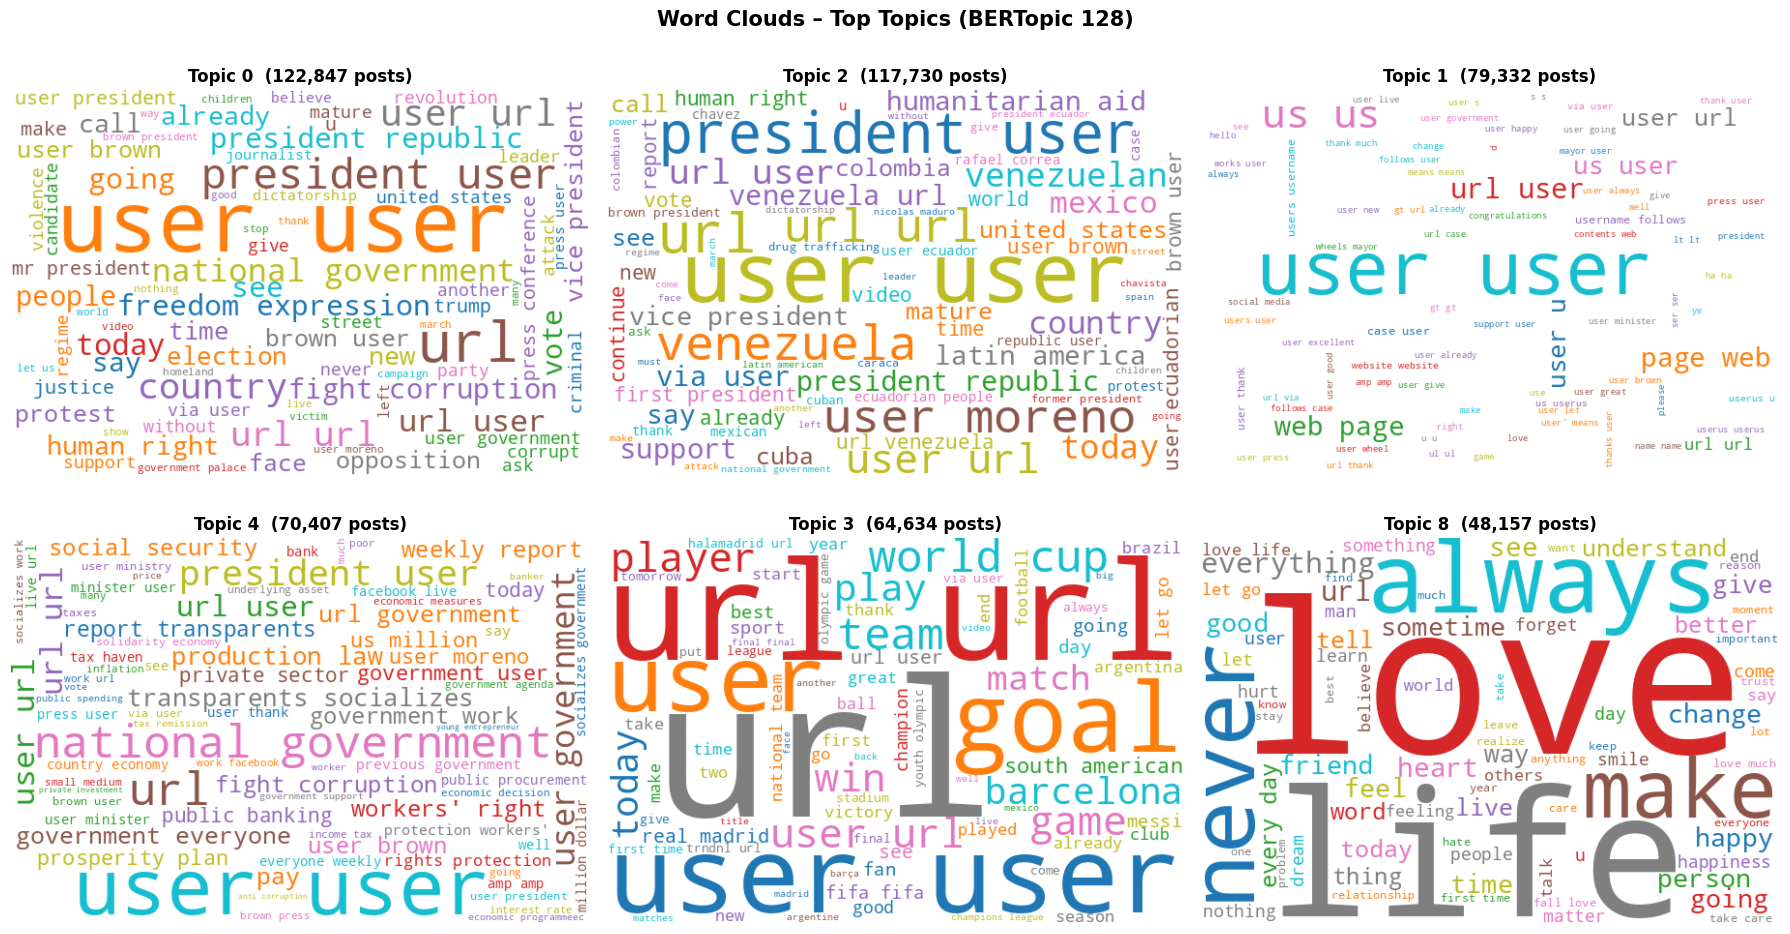

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

TOP_N = 6

top_topics = (df[df['BERTopic_topic_128'] != -1]['BERTopic_topic_128']
              .value_counts()
              .head(TOP_N)
              .index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, topic in zip(axes, top_topics):
    texts = df[df['BERTopic_topic_128'] == topic]['translated_post'].dropna().str.cat(sep=' ')

    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='tab10').generate(texts)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {topic}  ({(df["BERTopic_topic_128"] == topic).sum():,} posts)',
                 fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds – Top Topics (BERTopic 128)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

TOP_N = 6

top_topics = (df[df['BERTopic_topic_128'] != -1]['BERTopic_topic_128']
              .value_counts()
              .head(TOP_N)
              .index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, topic in zip(axes, top_topics):
    texts = df[df['BERTopic_topic_128'] == topic]['translated_post'].dropna().tolist()

    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=200)
    X = vectorizer.fit_transform(texts)
    bigram_freq = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))

    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='tab10').generate_from_frequencies(bigram_freq)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {topic}  ({len(texts):,} posts)', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Bigram Word Clouds – Top Topics (BERTopic 128)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df[df['BERTopic_topic_128'] == 3]